<a href="https://colab.research.google.com/github/dvorhub/top-face-media/blob/main/TopFace_Media.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Предисловие
Здравствуйте! Такого большого количества претендентов на роль аналитика данных неожиданно много, поэтому начнем вступление с небольшой шутки и продолжим.

**Руководитель:** 'Отчет должен быть читабельным и понятным для руководителя отдела'

**Как выглядит задачка в итоге:**
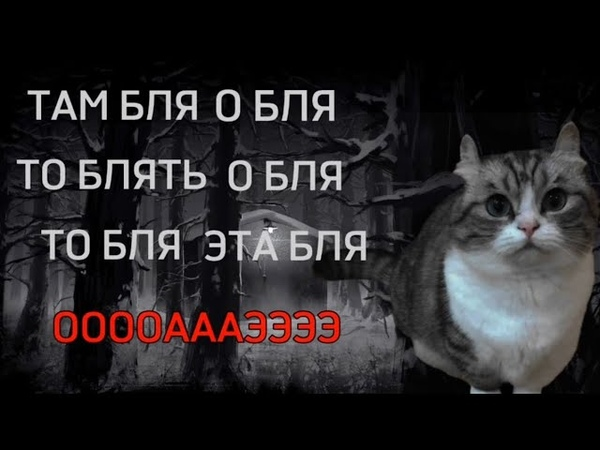

# Описание


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
financial_id = '1r3grFMz_k-XuWhRNLOAZCoLDdVYg2C7X'
financial_url = f'https://drive.google.com/uc?id={financial_id}'

df_financial = pd.read_csv(financial_url)

In [ ]:
df_financial.head()

,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Account
0,42,NaN,"36 220,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
1,657,первая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
2,657,вторая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
3,594,NaN,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
4,665,NaN,"10 000,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович


In [ ]:
df_financial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             451 non-null    int64 
 1   Причина дубля  301 non-null    object
 2   Ноябрь 2022    156 non-null    object
 3   Декабрь 2022   159 non-null    object
 4   Январь 2023    139 non-null    object
 5   Февраль 2023   145 non-null    object
 6   Март 2023      168 non-null    object
 7   Апрель 2023    174 non-null    object
 8   Май 2023       190 non-null    object
 9   Июнь 2023      190 non-null    object
 10  Июль 2023      195 non-null    object
 11  Август 2023    199 non-null    object
 12  Сентябрь 2023  186 non-null    object
 13  Октябрь 2023   182 non-null    object
 14  Ноябрь 2023    171 non-null    object
 15  Декабрь 2023   146 non-null    object
 16  Январь 2024    95 non-null     object
 17  Февраль 2024   101 non-null    object
 18  Account        451 non-null   

In [ ]:
df_financial.isna().sum()

,0
id,0
Причина дубля,150
Ноябрь 2022,295
Декабрь 2022,292
Январь 2023,312
Февраль 2023,306
Март 2023,283
Апрель 2023,277
Май 2023,261
Июнь 2023,261


In [ ]:
df_financial['id'].duplicated().sum()

np.int64(137)

In [ ]:
df_duplicated_id = df_financial[df_financial['id'].duplicated(keep=False)]
df_duplicated_id.head(10)

,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Account
1,657,первая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
2,657,вторая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
9,592,первая часть оплаты,"92 302,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
10,592,вторая часть оплаты,"12 340,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
13,704,первая часть оплаты,"35 365,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Михайлов Андрей Сергеевич
14,704,вторая часть оплаты,"945,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Михайлов Андрей Сергеевич
15,704,вторая часть оплаты,"4 715,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Михайлов Андрей Сергеевич
25,716,первая часть оплаты,"18 640,00","18 710,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Соколова Анастасия Викторовна
26,716,вторая часть оплаты,"3 165,00","2 110,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Соколова Анастасия Викторовна
33,461,первая часть оплаты,"103 230,00","103 230,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Иванова Мария Сергеевна


In [ ]:
# Проверяем все ли дубликаты имеют одинаковый Account
account_check = df_duplicated_id.groupby('id')['Account'].nunique()
different_account = account_check[account_check > 1]

if different_account.empty:
    print("Все дубликаты id имеют одинаковый Account.")
else:
    print(f"Найдены конфликты для id: {different_account.index.tolist()}")

Все дубликаты id имеют одинаковый Account.


In [ ]:
df_financial['Причина дубля'].value_counts(dropna=False)

,count
Причина дубля,
NaN,150
первая часть оплаты,114
вторая часть оплаты,99
доп работы,38
основные работы,38
изменение ЮЛ,11
"карты, банки",1


In [ ]:
df_financial.isin(['стоп', 'в ноль', 'end']).sum()

,0
id,0
Причина дубля,0
Ноябрь 2022,12
Декабрь 2022,16
Январь 2023,4
Февраль 2023,7
Март 2023,6
Апрель 2023,9
Май 2023,9
Июнь 2023,17


In [ ]:
# Проверяем точное кол-во текстовых значений
count_stop = (df_financial == 'стоп').sum().sum()
count_zero = (df_financial == 'в ноль').sum().sum()
count_end = (df_financial == 'end').sum().sum()

print(f"количество 'стоп': {count_stop}")
print(f"количество 'в ноль': {count_zero}")
print(f"количество 'end': {count_end}")

# Замениим end -> стоп, логика у них одинаковая по ТЗ
df_financial.replace('end', 'стоп', inplace=True)

количество 'стоп': 72
количество 'в ноль': 129
количество 'end': 1


In [ ]:
# Смотрим сколько 'стоп' и 'в ноль' встречается в месяцах
month_cols = [col for col in df_financial.columns if col not in ['id', 'Причина дубля', 'Account']]

result = []

for month in month_cols:
  counts = df_financial[month].value_counts()
  result.append({
      'Месяц': month,
      'стоп': counts.get('стоп', 0),
      'в ноль': counts.get('в ноль', 0)
  })

df_monthly_counts = pd.DataFrame(result)
df_monthly_counts

,Месяц,стоп,в ноль
0,Ноябрь 2022,4,8
1,Декабрь 2022,14,2
2,Январь 2023,0,4
3,Февраль 2023,2,5
4,Март 2023,2,4
5,Апрель 2023,3,6
6,Май 2023,1,8
7,Июнь 2023,5,12
8,Июль 2023,1,12
9,Август 2023,7,12


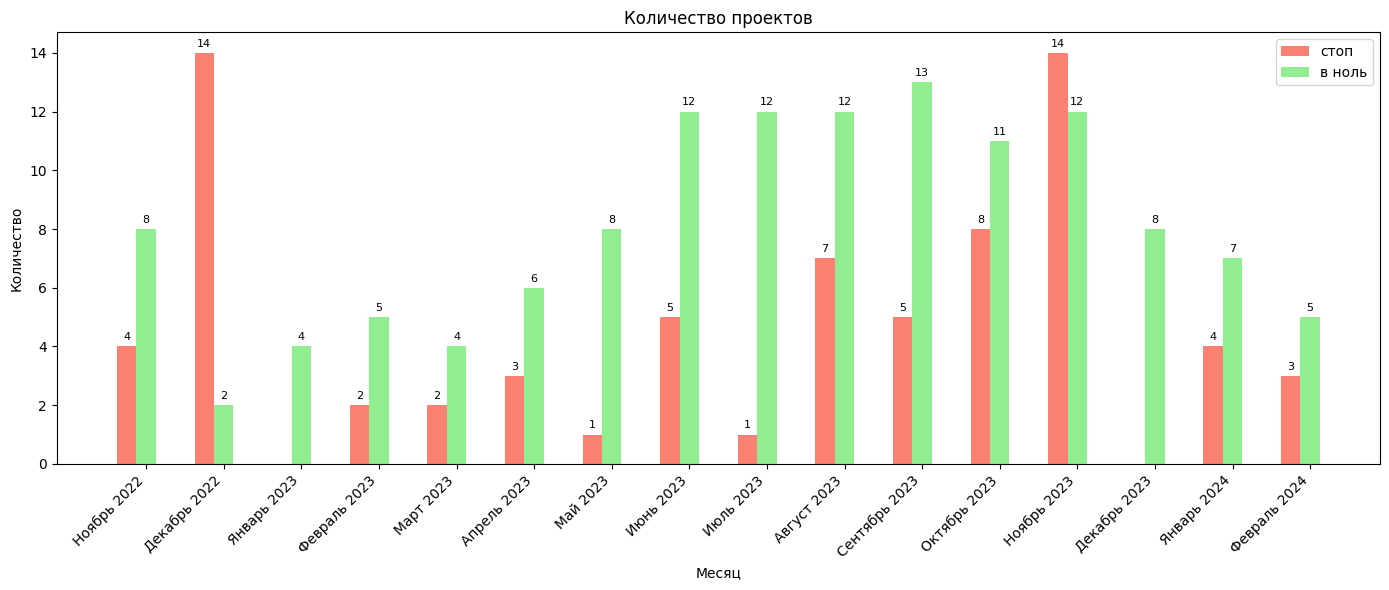

In [ ]:
# Строим простую гистограмму для наглядного и более точного понимания
x = np.arange(len(df_monthly_counts))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
rects1 = ax.bar(x - width, df_monthly_counts['стоп'], width, label='стоп', color='salmon')
rects2 = ax.bar(x, df_monthly_counts['в ноль'], width, label='в ноль', color='lightgreen')

ax.set_xlabel('Месяц')
ax.set_ylabel('Количество')
ax.set_title('Количество проектов')
ax.set_xticks(x)
ax.set_xticklabels(df_monthly_counts['Месяц'], rotation=45, ha='right')
ax.legend()

for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Быстрый вывод:
# - Сезонное закрытие проектов 'в ноль' в летний-осенний период
# - Сезонное завершение проектов 'стоп' ближе к зиме

In [ ]:
# Смотрим на проекты которые имеют 'стоп'
df_stoped = df_financial[df_financial.eq('стоп').any(axis=1)]

df_stoped.head(10)

,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Account
1,657,первая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
2,657,вторая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
3,594,NaN,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
19,572,изменение ЮЛ,"56 200,00",стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
20,573,изменение ЮЛ,"69 210,00",стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
21,574,изменение ЮЛ,"46 755,00",стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
22,575,изменение ЮЛ,"25 020,00",стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
23,576,изменение ЮЛ,"36 365,00",стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
27,613,первая часть оплаты,в ноль,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
28,615,первая часть оплаты,в ноль,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович


In [ ]:
# Так же смотрим на проекты которые имеют 'в ноль'
df_zeros = df_financial[df_financial.eq('в ноль').any(axis=1)]

df_zeros.head(10)

,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Account
8,579,NaN,в ноль,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
12,620,NaN,в ноль,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
27,613,первая часть оплаты,в ноль,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
28,615,первая часть оплаты,в ноль,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
29,617,первая часть оплаты,в ноль,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
30,643,первая часть оплаты,в ноль,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
56,705,вторая часть оплаты,в ноль,"4 220,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Смирнова Ольга Владимировна
83,453,NaN,в ноль,"39 245,00","44 320,00","177 635,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
114,697,доп работы,NaN,в ноль,в ноль,в ноль,"75 000,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
123,728,первая часть оплаты,NaN,"780 000,00",в ноль,в ноль,в ноль,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Попова Екатерина Николаевна


In [ ]:
# Проверяем для всех ли проектов указан Account, нет ли случайно NaN
# Видим, что есть 2 проекта без Account 'без А/М'
df_financial['Account'].value_counts(dropna=False)

# Вывод:
# 'без А/М' - не участвет в расчете месяцам и по годам для менеджеров, только в итоговом отчете по годам.

,count
Account,
Васильев Артем Александрович,111
Попова Екатерина Николаевна,85
Соколова Анастасия Викторовна,82
Смирнова Ольга Владимировна,74
Иванова Мария Сергеевна,46
Кузнецов Михаил Иванович,29
Михайлов Андрей Сергеевич,19
без А/М,2
Федорова Марина Васильевна,2


# Логические выступления:

‘в ноль’ –  отгрузка проекта в данном месяце равна 0, значит для коэффициента пролонгации нужно взять отгрузку предыдущего месяца (только если все части оплаты равны 0)

* В задании написано 'только если все части оплаты', можно предположить, что основные работы и доп работы - это не разные 'части' оплаты, а оплата за разные услуги. Хотя они тоже имеют стоп и в ноль, с которыми надо правильно отработать.

## Логика по примеру id = 697 и id = 211:

1. При объединении дублирующихся записей по id, мы проверяем каждый месяц. Ноябрь 2022 = NaN, NaN; Декабрь 2022 = 71 000,00, в ноль (это значит, что при объединении записей Декабрь 2022 будет равен = 71 000,00);

2. Январь 2023 = NaN, в ноль значит мы проверяем оплату в предыдущий месяц. Если такая оплата есть, тогда записываем ее в Январь 2023. В нашем случае Январь 2023 будет равен = 71 000,00.

## Логика преобразовния:

1. Заменить 'в ноль' -> 0, 'стоп' -> -1 (Колонки должны быть тпа float, поэтому ставим понятные логические флаги)

2. Изменить тип данных на float

3. Объединить дублирующиеся id. при объединении дублирующихся записей по id, мы проверяем каждый месяц, например:
  - Ноябрь 2022 = NaN, NaN (в обоих случаях записи) -> оставляем NaN
  - Декабрь 2022 = 71 000,00 в первой записи и в ноль(мы уже заменили на числовой 0) во второй, тогда Декабрь 2022 = 71 000,00 (71 000,00 + 0 = 71 000,00)
  - Январь 2023 = NaN, в ноль (мы уже заменили на числовой 0) -> проверяем оплату в предыдущий месяц (Декабрь 2022 = 71 000,00), значит Январь 2023 = 71 000,00. Если в предыдущем месяце было значение NaN ставим NaN
  - Март 2023 = 44 250,00, 75 000,00 -> Суммируем части оплаты: 44 250,00 + 75 000,00 = 119250
  

In [ ]:
# Выполняем преобразование данных
for col in month_cols:
    df_financial[col] = (
        df_financial[col]
        .astype(str)
        .replace({'в ноль': '0', 'стоп': '-1'})
        .str.replace('\xa0', '', regex=False)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

# Агрегируем дублирующиеся проекты
sum_double = (
    df_financial
    .groupby(['id', 'Account'])[month_cols]
    .sum(min_count=1)
)

# Записываем логический -1 для 'стоп' проектов
mask_stop = df_financial.groupby(['id', 'Account'])[month_cols].min() == -1
sum_double[mask_stop] = -1

# Меняем 'в ноль' (0) в первом месяце на NaN
if len(month_cols) > 0:
    sum_double[month_cols[0]] = sum_double[month_cols[0]].replace(0, np.nan)

# Меняем 'в ноль' (0) на значение из предыдущего месяца
for i in range(1, len(month_cols)):
    curr_col = month_cols[i]
    prev_col = month_cols[i-1]

    mask_zero = sum_double[curr_col] == 0
    sum_double.loc[mask_zero, curr_col] = sum_double.loc[mask_zero, prev_col]

df_result_financial = sum_double.reset_index()
df_result_financial['Account'] = df_result_financial['Account'].astype('category')

df_result_financial.head(10)

# Вывод:
# - Мы просуммировали значения
# - Избавились от дубликатов
# - Заменили в ноль' (0) на NaN и значение из предыдущего месяца
# - Оставили флаг (-1) для проектов 'стоп' - важно для отчета

,id,Account,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024
0,15,Иванова Мария Сергеевна,439280.0,439280.0,102433.75,102433.75,102433.75,138158.0,138158.0,102433.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16,Иванова Мария Сергеевна,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,31,Васильев Артем Александрович,55100.0,55100.0,NaN,44775.00,44775.00,44775.0,44775.0,44775.00,44775.0,44775.0,44775.0,44775.0,44775.0,44775.0,44775.0,46200.0
3,39,Попова Екатерина Николаевна,137700.0,137700.0,149206.50,149206.50,149206.50,149206.5,149206.5,149206.50,149206.5,149206.5,149206.5,149206.5,149206.5,149206.5,NaN,NaN
4,42,Васильев Артем Александрович,36220.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,45,Попова Екатерина Николаевна,35150.0,47400.0,49130.00,64475.00,71640.00,58995.0,62100.0,61635.00,70755.0,36125.0,85090.0,96680.0,88400.0,77530.0,NaN,NaN
6,46,Смирнова Ольга Владимировна,37939.5,37939.5,39838.50,39298.50,39298.50,39298.5,39298.5,39298.50,39298.5,39298.5,39298.5,39298.5,39298.5,39298.5,NaN,NaN
7,48,Смирнова Ольга Владимировна,NaN,NaN,NaN,39726.00,39726.00,39726.0,NaN,NaN,NaN,NaN,39726.0,39726.0,39726.0,NaN,45175.5,44635.5
8,49,Смирнова Ольга Владимировна,85842.0,85842.0,83358.00,83358.00,83358.00,83358.0,83358.0,83358.00,84582.0,84582.0,84582.0,84582.0,84582.0,84582.0,NaN,NaN
9,54,Смирнова Ольга Владимировна,NaN,NaN,NaN,NaN,41067.00,38461.5,32139.0,31333.50,32139.0,32139.0,49666.5,50094.0,50949.0,50949.0,NaN,NaN


# Таблица
df_prolongations

In [ ]:
prolongations_id = '1n2CIsPZYOIqMfV7b3aUtp1efc9U96xVt'
prolongations_url = f'https://drive.google.com/uc?id={prolongations_id}'

df_prolongations = pd.read_csv(prolongations_url)

In [ ]:
df_prolongations.head()

,id,month,AM
0,42,ноябрь 2022,Васильев Артем Александрович
1,453,ноябрь 2022,Васильев Артем Александрович
2,548,ноябрь 2022,Михайлов Андрей Сергеевич
3,87,ноябрь 2022,Соколова Анастасия Викторовна
4,429,ноябрь 2022,Соколова Анастасия Викторовна


In [ ]:
df_prolongations.duplicated().sum()

np.int64(3)

In [ ]:
prolongations_duplicated = df_prolongations[df_prolongations.duplicated()]
prolongations_duplicated

,id,month,AM
161,682,март 2023,Васильев Артем Александрович
164,697,март 2023,Васильев Артем Александрович
187,600,апрель 2023,Васильев Артем Александрович


In [ ]:
df_prolongations[df_prolongations['id'] == 682]

,id,month,AM
160,682,март 2023,Васильев Артем Александрович
161,682,март 2023,Васильев Артем Александрович
465,682,декабрь 2023,Васильев Артем Александрович


In [ ]:
df_prolongations.shape

(477, 3)

In [ ]:
df_prolongations = (
    df_prolongations
    .drop_duplicates(subset=['id', 'month', 'AM'])
)

In [ ]:
df_prolongations.head()

,id,month,AM
0,42,ноябрь 2022,Васильев Артем Александрович
1,453,ноябрь 2022,Васильев Артем Александрович
2,548,ноябрь 2022,Михайлов Андрей Сергеевич
3,87,ноябрь 2022,Соколова Анастасия Викторовна
4,429,ноябрь 2022,Соколова Анастасия Викторовна


In [ ]:
# AM – ФИО ответственного аккаунт-менеджера (данные первичны по отношению к financial_data).
# При расчетах кф учитывать AM, если он изменился значит кф расчитывается для другого аккаунт-менеджера
df_prolongations.groupby('id')['AM'].nunique().loc[lambda x: x > 1].index

Index([ 39,  46,  48,  49,  87, 107, 112, 154, 196, 199, 281, 361, 441, 448,
       495, 519, 547, 569, 580, 583, 586, 597, 610, 629, 645, 690, 712, 713,
       743, 744, 771, 783, 785, 804, 808, 848, 914],
      dtype='int64', name='id')

# Логика расчетов

Логика расчетов тесно связано с преобразованием данных, тк мы заменили текстовые значения на числовые(логические) флаги которые явно отображают что происхоидло с проектом в той или иной месяц. Выше представлены все объяснения преобразований, но пройедмся еще раз.

1. Мы заменили 'в ноль' -> 0, 'стоп' -> -1, значит они участвуют в расчетах по определнным правилам. 0 при суммировании никак не меняет исходное число, а -1 (если стоит в последний месяц реализации или раньше) заменяется на NaN, чтобы также не участвовать в расчетах.

2. Объединить дублирующиеся id. при объединении дублирующихся записей по id, мы проверяем каждый месяц, например:
- Ноябрь 2022 = NaN, NaN (в обоих случаях записи) -> оставляем NaN
- Декабрь 2022 = 71 000,00 в первой записи и в ноль(мы уже заменили на числовой 0) во второй, тогда Декабрь 2022 = 71 000,00 (71 000,00 + 0 = 71 000,00)
- Январь 2023 = NaN, в ноль (мы уже заменили на числовой 0) -> проверяем оплату в предыдущий месяц (Декабрь 2022 = 71 000,00), значит Январь 2023 = 71 000,00. Если в предыдущем месяце было значение NaN ставим NaN
- Март 2023 = 44 250,00, 75 000,00 -> Суммируем части оплаты: 44 250,00 + 75 000,00 = 119250



In [ ]:
finance_month_cols = [col for col in df_result_financial.columns if col not in ['id', 'Account']]

# Объединяем данные
df_all_data = df_prolongations.merge(df_result_financial.drop(columns=['Account']), on='id', how='left').replace(-1, np.nan)

# Проверяем проекты 'стоп' (-1) до или в месяц реализации
def has_invalid_stop(month):
    end_month = str(month['month']).lower()

    # Находим индекс месяца завершения в списке колонок
    month_map = {month.lower(): i for i, month in enumerate(finance_month_cols)}
    end_idx = month_map[end_month]

    # Берем только те колонки месяцев, которые идут до месяца завершения
    relevant_months = finance_month_cols[:end_idx + 1]

    # Если в этих месяцах есть хотя бы один -1, значит это "незаконный" стоп
    return (month[relevant_months] == -1).any()

# Применяем фильтр: исключаем только те проекты, где стоп был "вовремя" или раньше
df_all_data['is_bad_stop'] = df_all_data.apply(has_invalid_stop, axis=1)
df_all_data = df_all_data[df_all_data['is_bad_stop'] == False]

result = []

for i, current_month in enumerate(finance_month_cols):
    year = current_month[-4:]

    # КФ 1-го месяца
    if i >= 1:
        prev_1 = finance_month_cols[i-1]
        mask_k1 = (df_all_data['month'].str.lower() == prev_1.lower())

        df_k1 = df_all_data[mask_k1]
        for am, group in df_k1.groupby('AM'):
            result.append({
                'Год': year,
                'Пролонгирован': current_month,
                'Менеджер': am,
                'end_month_k1': group[prev_1].sum(),
                'prolong_month_k1': group[current_month].sum(),
                'count_k1': group['id'].nunique()
            })

    # КФ 2-го месяца
    if i >= 2:
        prev_1 = finance_month_cols[i-1]
        prev_2 = finance_month_cols[i-2]

        # Проект завершился 2 месяца назад и в предыдущий месяц не было пролонгации
        mask_k2 = (
            (df_all_data['month'].str.lower() == prev_2.lower()) &
            (df_all_data[prev_1].fillna(0) <= 0)
        )

        df_k2 = df_all_data[mask_k2]
        for am, group in df_k2.groupby('AM'):
            result.append({
                'Год': year,
                'Пролонгирован': current_month,
                'Менеджер': am,
                'end_month_k2': group[prev_2].sum(),
                'prolong_month_k2': group[current_month].sum(),
                'count_k2': group['id'].nunique()
            })

df_result = pd.DataFrame(result).groupby(['Год', 'Пролонгирован', 'Менеджер']).sum().reset_index()

In [ ]:
# Таблица: Коэффициенты пролонгации для каждого менеджера по месяцам.
df_result_am_month = df_result[df_result['Менеджер'] != 'без А/М'].copy()

df_result_am_month['В 1-й месяц'] = (
    df_result_am_month['prolong_month_k1'] / df_result_am_month['end_month_k1']
).replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0).round(2)

df_result_am_month['Во 2-й месяц'] = (
    df_result_am_month['prolong_month_k2'] / df_result_am_month['end_month_k2']
).replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0).round(2)

df_result_am_month = df_result_am_month[
    ['Пролонгирован', 'Менеджер', 'В 1-й месяц', 'Во 2-й месяц']
]
df_result_am_month.head(10)


# df_result_am_month = df_result[df_result['Менеджер'] != 'без А/М'].copy()

# df_result_am_month['КФ1'] = (
#     df_result_am_month['prolong_month_k1'] / df_result_am_month['end_month_k1']
# ).replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0).round(2)

# df_result_am_month['КФ2'] = (
#     df_result_am_month['prolong_month_k2'] / df_result_am_month['end_month_k2']
# ).replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0).round(2)

# df_result_am_month['count_k1'] = df_result_am_month['count_k1'].fillna(0).astype(int)
# df_result_am_month['count_k2'] = df_result_am_month['count_k2'].fillna(0).astype(int)

# df_result_am_month = df_result_am_month[
#     ['Пролонгирован', 'Менеджер', 'КФ1', 'count_k1', 'КФ2', 'count_k2']
# ]

# df_result_am_month.columns = ['Пролонгирован', 'Менеджер', 'КФ1', 'Проектов КФ1', 'КФ2', 'Проектов КФ2']

# df_result_am_month.head(10)

,Пролонгирован,Менеджер,В 1-й месяц,Во 2-й месяц
0,Декабрь 2022,Васильев Артем Александрович,0.42,0.00
1,Декабрь 2022,Иванова Мария Сергеевна,0.00,0.00
2,Декабрь 2022,Михайлов Андрей Сергеевич,0.91,0.00
3,Декабрь 2022,Попова Екатерина Николаевна,0.30,0.00
4,Декабрь 2022,Соколова Анастасия Викторовна,0.84,0.00
5,Август 2023,Васильев Артем Александрович,0.48,0.00
6,Август 2023,Иванова Мария Сергеевна,0.54,0.00
7,Август 2023,Попова Екатерина Николаевна,0.48,0.00
8,Август 2023,Смирнова Ольга Владимировна,0.37,1.55
9,Август 2023,Соколова Анастасия Викторовна,0.54,0.00


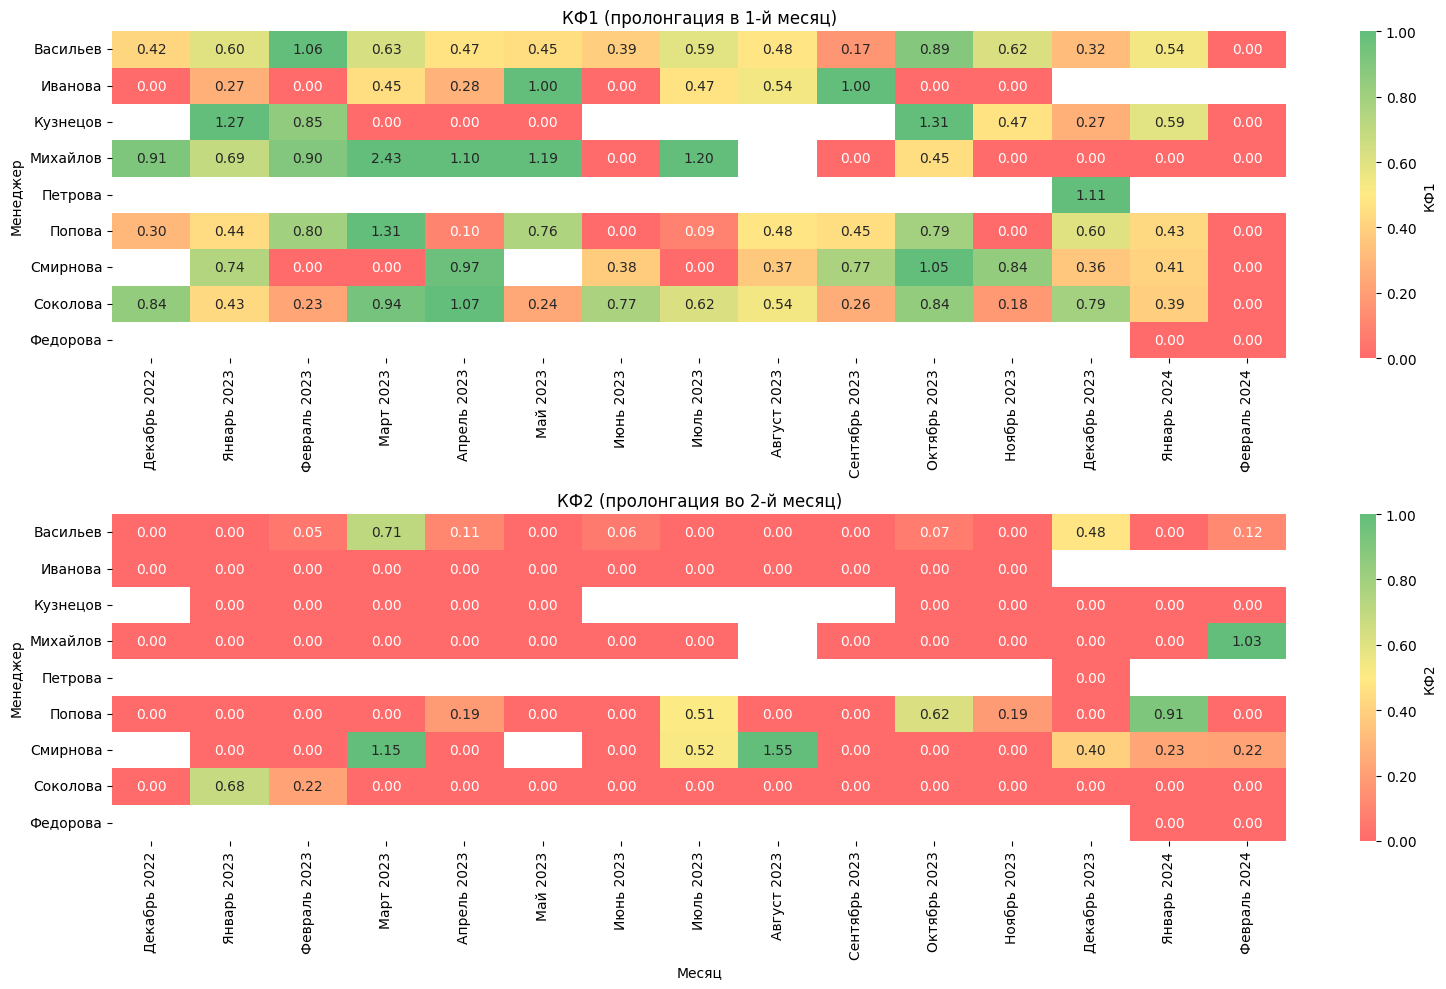

In [ ]:
# Вероятно за основу взять только 2023 год, тк он является наиболее информативным по показателям
month_order = [
    'Декабрь 2022',
    'Январь 2023', 'Февраль 2023', 'Март 2023', 'Апрель 2023',
    'Май 2023', 'Июнь 2023', 'Июль 2023', 'Август 2023',
    'Сентябрь 2023', 'Октябрь 2023', 'Ноябрь 2023', 'Декабрь 2023',
    'Январь 2024', 'Февраль 2024'
]

cmap_kp = LinearSegmentedColormap.from_list('kp', ['#FF6B6B', '#FFEB84', '#63BE7B'], N=256)

df = df_result_am_month.copy()
df['Фамилия'] = df['Менеджер'].str.split().str[0]
df['Пролонгирован'] = pd.Categorical(df['Пролонгирован'], categories=month_order, ordered=True)
df = df.sort_values('Пролонгирован')

pivot_k1 = df.pivot(index='Фамилия', columns='Пролонгирован', values='В 1-й месяц')
pivot_k2 = df.pivot(index='Фамилия', columns='Пролонгирован', values='Во 2-й месяц')

pivot_k1 = pivot_k1.reindex(columns=month_order)
pivot_k2 = pivot_k2.reindex(columns=month_order)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# КФ1
sns.heatmap(pivot_k1, annot=True, fmt='.2f', cmap=cmap_kp, vmin=0, vmax=1,
            cbar_kws={'label': 'КФ1', 'format': '%.2f'}, ax=ax1)
ax1.set_title('КФ1 (пролонгация в 1-й месяц)')
ax1.set_xlabel('')
ax1.set_ylabel('Менеджер')

# КФ2
sns.heatmap(pivot_k2, annot=True, fmt='.2f', cmap=cmap_kp, vmin=0, vmax=1,
            cbar_kws={'label': 'КФ2', 'format': '%.2f'}, ax=ax2)
ax2.set_title('КФ2 (пролонгация во 2-й месяц)')
ax2.set_xlabel('Месяц')
ax2.set_ylabel('Менеджер')

plt.tight_layout()
plt.show()

In [ ]:
# Таблица: Коэффициенты пролонгации для каждого менеджера по годам
df_result_am_year = (
    df_result[df_result['Менеджер'] != 'без А/М']
    .groupby(['Год', 'Менеджер'])
    .sum(numeric_only=True)
    .reset_index()
)

df_result_am_year['В 1-й месяц'] = (
    df_result_am_year['prolong_month_k1'] / df_result_am_year['end_month_k1']
).replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0).round(2)

df_result_am_year['Во 2-й месяц'] = (
    df_result_am_year['prolong_month_k2'] / df_result_am_year['end_month_k2']
).replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0).round(2)

df_result_am_year = df_result_am_year[
    ['Год', 'Менеджер', 'В 1-й месяц', 'Во 2-й месяц']
]

df_result_am_year.head()

# # Группируем данные за год по менеджерам
# df_result_am_year = (
#     df_result[df_result['Менеджер'] != 'без А/М']
#     .groupby(['Год', 'Менеджер'])
#     .sum(numeric_only=True)
#     .reset_index()
# )

# # Расчет КФ1 и КФ2
# df_result_am_year['В 1-й месяц'] = (
#     df_result_am_year['prolong_month_k1'] / df_result_am_year['end_month_k1']
# ).replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0).round(2)

# df_result_am_year['Во 2-й месяц'] = (
#     df_result_am_year['prolong_month_k2'] / df_result_am_year['end_month_k2']
# ).replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0).round(2)

# # Приводим количество проектов к целому числу
# df_result_am_year['count_k1'] = df_result_am_year['count_k1'].fillna(0).astype(int)
# df_result_am_year['count_k2'] = df_result_am_year['count_k2'].fillna(0).astype(int)

# # Формируем финальный вид
# df_result_am_year = df_result_am_year[
#     ['Год', 'Менеджер', 'В 1-й месяц', 'count_k1', 'Во 2-й месяц', 'count_k2']
# ]

# # Для удобства переименуем колонки
# df_result_am_year.rename(columns={'count_k1': 'Проектов КФ1', 'count_k2': 'Проектов КФ2'}, inplace=True)

# df_result_am_year.head()

,Год,Менеджер,В 1-й месяц,Во 2-й месяц
0,2022,Васильев Артем Александрович,0.42,0.0
1,2022,Иванова Мария Сергеевна,0.00,0.0
2,2022,Михайлов Андрей Сергеевич,0.91,0.0
3,2022,Попова Екатерина Николаевна,0.30,0.0
4,2022,Соколова Анастасия Викторовна,0.84,0.0


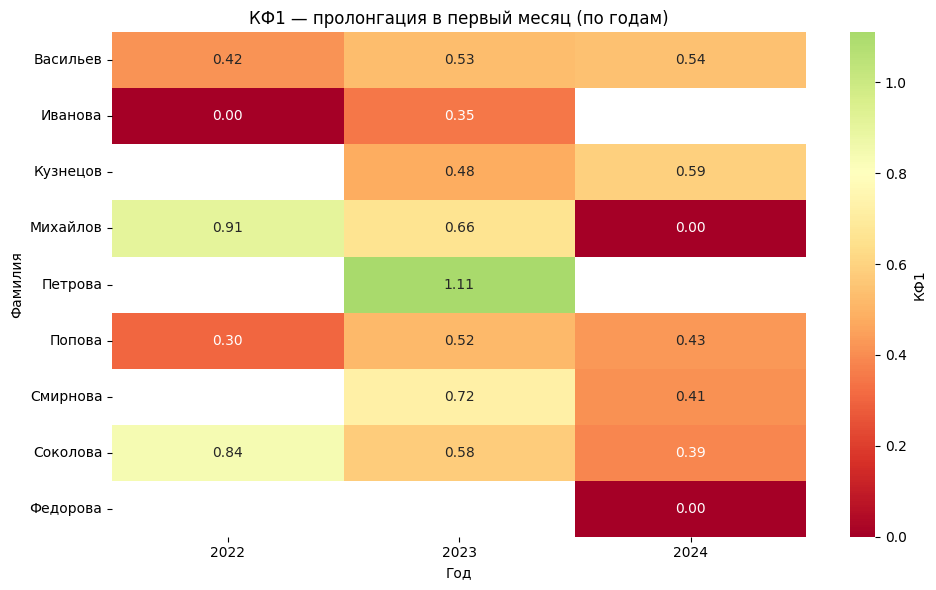

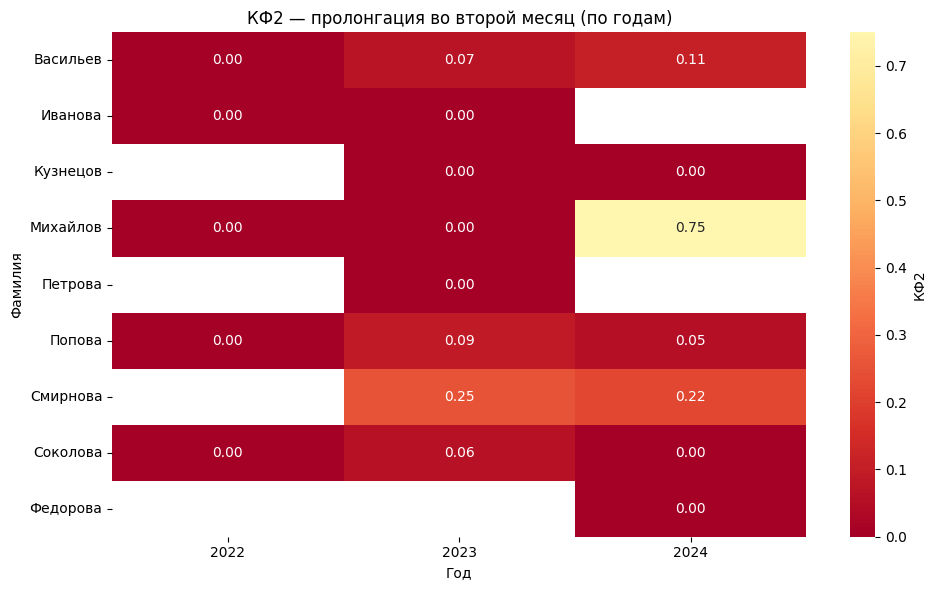

In [ ]:
df_year = df_result_am_year.copy()
df_year['Фамилия'] = df_year['Менеджер'].str.split().str[0]

# КФ1
pivot_k1 = df_year.pivot(index='Фамилия', columns='Год', values='В 1-й месяц')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_k1, annot=True, fmt='.2f', cmap='RdYlGn', center=0.8,
            cbar_kws={'label': 'КФ1'})
plt.title('КФ1 — пролонгация в первый месяц (по годам)')
plt.tight_layout()
plt.show()

# КФ2
pivot_k2 = df_year.pivot(index='Фамилия', columns='Год', values='Во 2-й месяц')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_k2, annot=True, fmt='.2f', cmap='RdYlGn', center=0.8,
            cbar_kws={'label': 'КФ2'})
plt.title('КФ2 — пролонгация во второй месяц (по годам)')
plt.tight_layout()
plt.show()

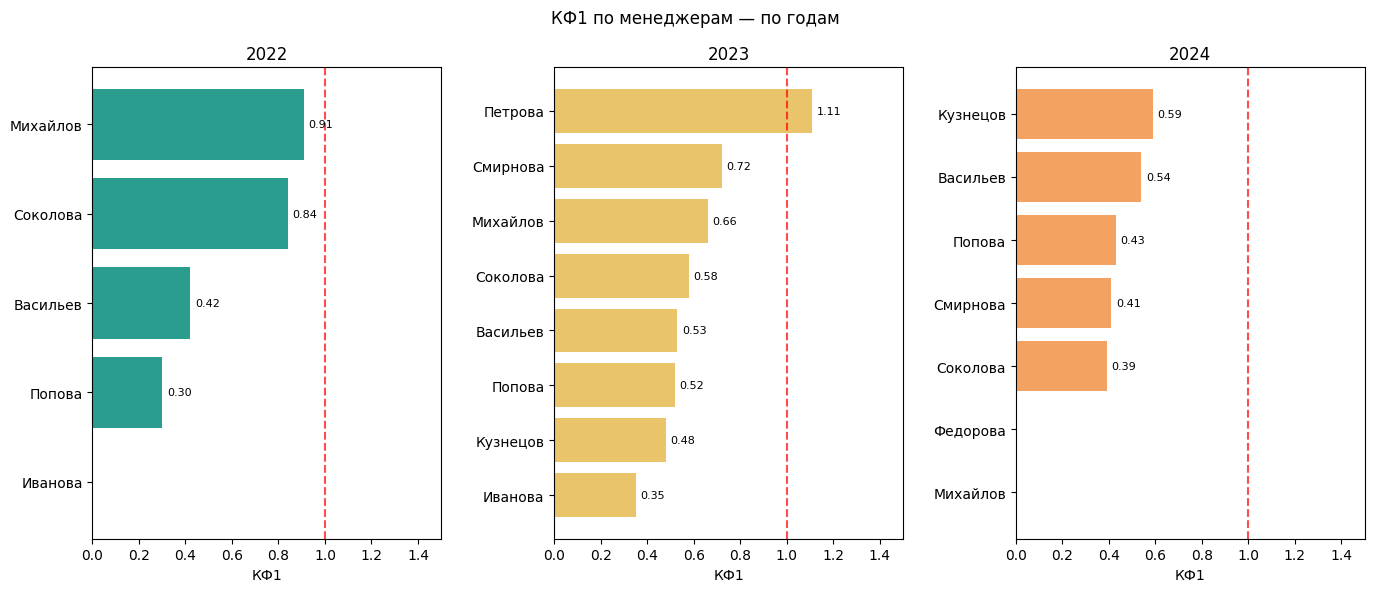

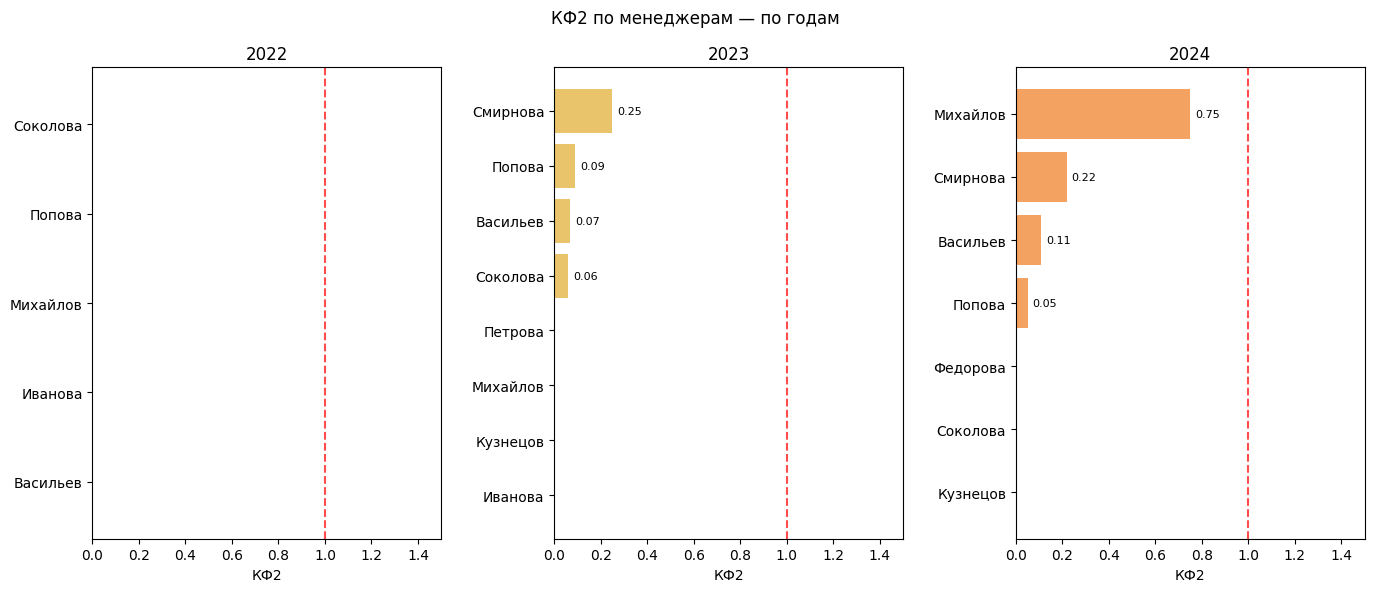

In [ ]:
df_year = df_result_am_year.copy()
df_year['Фамилия'] = df_year['Менеджер'].str.split().str[0]

years = sorted(df_year['Год'].unique())
colors = ['#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']

# КФ1
fig1, axes = plt.subplots(1, len(years), figsize=(14, 6))
for i, year in enumerate(years):
    data = df_year[df_year['Год'] == year].sort_values('В 1-й месяц', ascending=True)
    bars = axes[i].barh(data['Фамилия'], data['В 1-й месяц'], color=colors[i % len(colors)])
    axes[i].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    axes[i].set_title(f'{year}')
    axes[i].set_xlim(0, 1.5)
    axes[i].set_xlabel('КФ1')

    for bar in bars:
        width = bar.get_width()
        if width > 0:
            axes[i].text(width + 0.02, bar.get_y() + bar.get_height()/2,
                         f'{width:.2f}', ha='left', va='center', fontsize=8)
plt.suptitle('КФ1 по менеджерам — по годам', fontsize=12)
plt.tight_layout()
plt.show()

# КФ2
fig2, axes = plt.subplots(1, len(years), figsize=(14, 6))
for i, year in enumerate(years):
    data = df_year[df_year['Год'] == year].sort_values('Во 2-й месяц', ascending=True)
    bars = axes[i].barh(data['Фамилия'], data['Во 2-й месяц'], color=colors[i % len(colors)])
    axes[i].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    axes[i].set_title(f'{year}')
    axes[i].set_xlim(0, 1.5)
    axes[i].set_xlabel('КФ2')

    for bar in bars:
        width = bar.get_width()
        if width > 0:
            axes[i].text(width + 0.02, bar.get_y() + bar.get_height()/2,
                         f'{width:.2f}', ha='left', va='center', fontsize=8)
plt.suptitle('КФ2 по менеджерам — по годам', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Таблица: Коэффициенты пролонгации по годам для всего отдела
df_result_year = (
    df_result
    .groupby(['Год'])
    .sum(numeric_only=True)
    .reset_index()
)

df_result_year['В 1-й месяц'] = (
    df_result_year['prolong_month_k1'] / df_result_year['end_month_k1']
).replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0).round(2)

df_result_year['Во 2-й месяц'] = (
    df_result_year['prolong_month_k2'] / df_result_year['end_month_k2']
).replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0).round(2)

df_result_year = df_result_year[
    ['Год', 'В 1-й месяц', 'Во 2-й месяц']
]

df_result_year.head(10)

,Год,В 1-й месяц,Во 2-й месяц
0,2022,0.67,0.00
1,2023,0.54,0.06
2,2024,0.46,0.12


Построением графиков занимался не я, а мой подручный. Большое ему спасибо за это! Думаю, что главное понимать что на них написано и как написан код, чем пыхтеть по часу над каждым графиком.

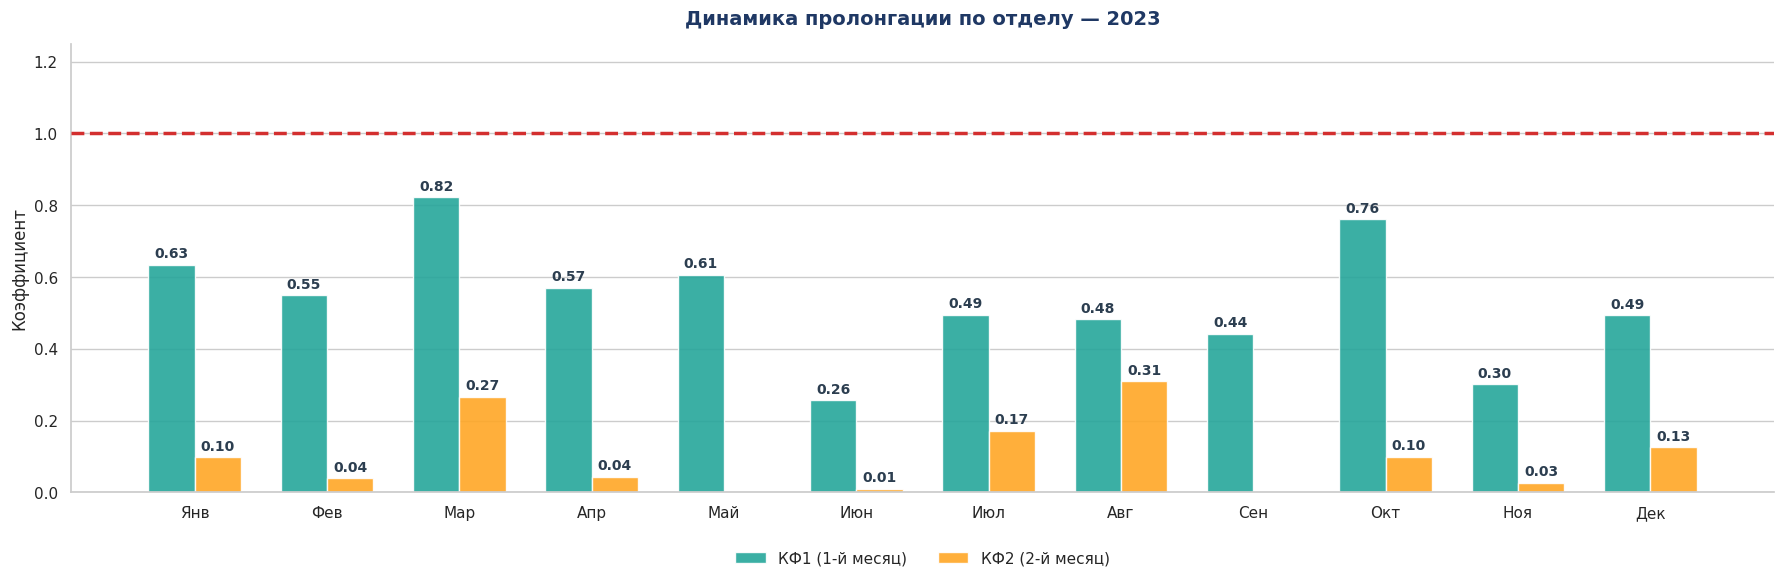

In [ ]:
sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid.axis': 'y'})

df = df_result_am_month.copy()
df_23 = df[df['Пролонгирован'].str.contains('2023')].copy()

avg_data = df_23.groupby('Пролонгирован', observed=False)[['В 1-й месяц', 'Во 2-й месяц']].mean()

months = ['Январь 2023', 'Февраль 2023', 'Март 2023', 'Апрель 2023',
          'Май 2023', 'Июнь 2023', 'Июль 2023', 'Август 2023',
          'Сентябрь 2023', 'Октябрь 2023', 'Ноябрь 2023', 'Декабрь 2023']

avg_data = avg_data.reindex(months).fillna(0)

month_labels = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

fig, ax = plt.subplots(figsize=(18, 6))

x = np.arange(len(months))
width = 0.35

rects1 = ax.bar(x - width/2, avg_data['В 1-й месяц'], width, label='КФ1 (1-й месяц)', color='#26a69a', alpha=0.9)
rects2 = ax.bar(x + width/2, avg_data['Во 2-й месяц'], width, label='КФ2 (2-й месяц)', color='#ffa726', alpha=0.9)

ax.axhline(y=1.0, color='#d32f2f', linestyle='--', linewidth=2.5, alpha=1, zorder=5)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.2f}', color='#2c3e50',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

ax.set_xticks(x)
ax.set_xticklabels(month_labels, fontsize=11)
ax.set_ylabel('Коэффициент', fontsize=12)
ax.set_title('Динамика пролонгации по отделу — 2023', fontsize=14, fontweight='bold', pad=14, color='#1F3864')
ax.set_ylim(0, 1.25)

ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=11)

plt.tight_layout()
plt.show()

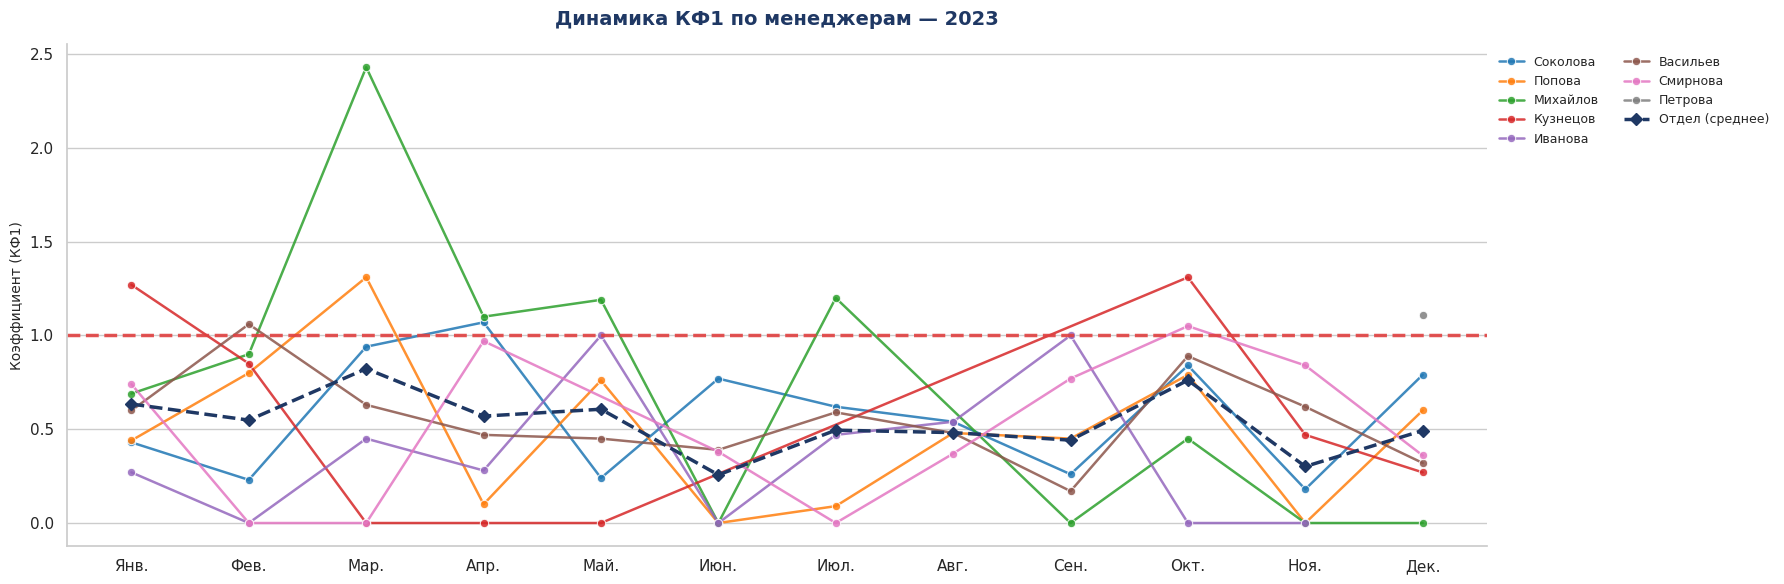

In [ ]:
sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

MONTHS_2023 = [
    'Январь 2023', 'Февраль 2023', 'Март 2023', 'Апрель 2023',
    'Май 2023', 'Июнь 2023', 'Июль 2023', 'Август 2023',
    'Сентябрь 2023', 'Октябрь 2023', 'Ноябрь 2023', 'Декабрь 2023'
]

df_23 = df_result_am_month[df_result_am_month['Пролонгирован'].isin(MONTHS_2023)].copy()
df_23['Фамилия'] = df_23['Менеджер'].apply(lambda x: str(x).split()[0])
df_23['Пролонгирован'] = pd.Categorical(df_23['Пролонгирован'], categories=MONTHS_2023, ordered=True)
df_23 = df_23.sort_values('Пролонгирован')
df_23['Месяц_Кратко'] = df_23['Пролонгирован'].apply(lambda x: x.split()[0][:3] + '.')

dept_k1 = df_23.groupby('Месяц_Кратко', sort=False, observed=False)['В 1-й месяц'].mean()

fig, ax = plt.subplots(figsize=(18, 6))

sns.lineplot(
    data=df_23,
    x='Месяц_Кратко',
    y='В 1-й месяц',
    hue='Фамилия',
    marker='o',
    markersize=6,
    linewidth=1.8,
    palette='tab10',
    alpha=0.85,
    ax=ax
)

ax.plot(dept_k1.index, dept_k1.values, color='#1F3864', lw=2.5, ls='--',
        marker='D', markersize=6, label='Отдел (среднее)', zorder=4)

ax.axhline(1.0, color='#E04040', lw=2.5, ls='--', alpha=0.9, zorder=2)

ax.set_ylabel('Коэффициент (КФ1)', fontsize=10)
ax.set_xlabel('')
ax.set_title('Динамика КФ1 по менеджерам — 2023', fontsize=14, fontweight='bold', pad=14, color='#1F3864')

ax.legend(frameon=False, fontsize=9, ncol=2, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

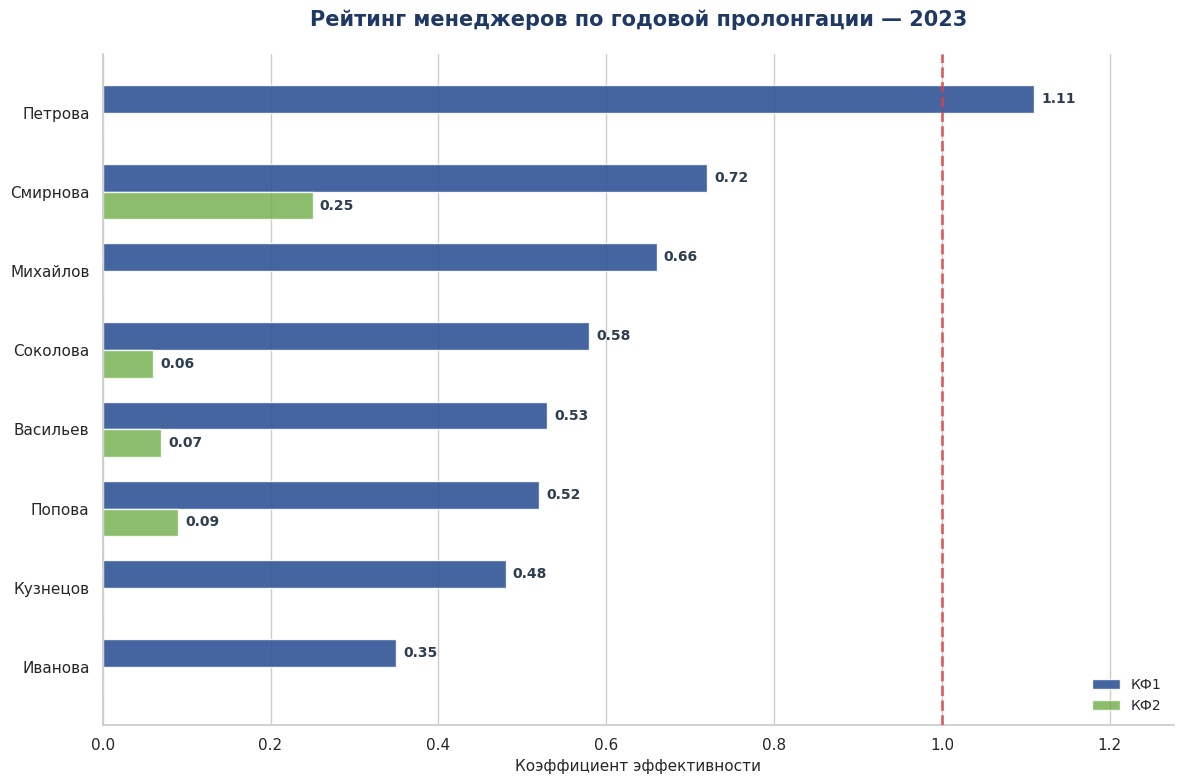

In [ ]:
target_year = 2023
if not df_result_am_year.empty:
    year_val = target_year if df_result_am_year['Год'].dtype in [np.int64, np.float64] else str(target_year)
    df_rank = df_result_am_year[df_result_am_year['Год'] == year_val].copy()
else:
    df_rank = pd.DataFrame()

if df_rank.empty:
    print(f"Данные за {target_year} год не найдены.")
else:
    df_rank[['В 1-й месяц', 'Во 2-й месяц']] = df_rank[['В 1-й месяц', 'Во 2-й месяц']].fillna(0)
    df_rank['Фамилия'] = df_rank['Менеджер'].apply(lambda x: str(x).split()[0])

    df_rank = df_rank.sort_values('В 1-й месяц', ascending=True)

    sns.set_theme(style='whitegrid', font='DejaVu Sans')
    plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid.axis': 'x'})

    y = np.arange(len(df_rank))
    height = 0.35
    fig, ax = plt.subplots(figsize=(12, 8))

    rects1 = ax.barh(y + height/2, df_rank['В 1-й месяц'], height, label='КФ1', color='#2F5496', alpha=0.9)
    rects2 = ax.barh(y - height/2, df_rank['Во 2-й месяц'], height, label='КФ2', color='#70AD47', alpha=0.8)

    ax.axvline(1.0, color='#E04040', lw=2, ls='--', alpha=0.8, zorder=5)

    def add_labels(rects):
        for rect in rects:
            width = rect.get_width()
            if np.isfinite(width) and width > 0:
                ax.annotate(f'{width:.2f}',
                            xy=(width, rect.get_y() + rect.get_height() / 2),
                            xytext=(5, 0),
                            textcoords="offset points",
                            ha='left', va='center',
                            fontsize=10, fontweight='bold', color='#2c3e50')

    add_labels(rects1)
    add_labels(rects2)

    max_x = df_rank['В 1-й месяц'].max()
    limit_x = max(max_x, 1.1) * 1.15 if np.isfinite(max_x) else 1.2

    ax.set_yticks(y)
    ax.set_yticklabels(df_rank['Фамилия'], fontsize=11)

    ax.set_xlim(0, limit_x)
    ax.set_xlabel('Коэффициент эффективности', fontsize=11)
    ax.set_title(f'Рейтинг менеджеров по годовой пролонгации — {target_year}',
                 fontsize=15, fontweight='bold', pad=20, color='#1F3864')

    ax.legend(frameon=False, loc='lower right', fontsize=10)

    plt.tight_layout()
    plt.show()